## Settings 

In [106]:
import os 
from pathlib import Path 

PROBLEMS = [
    "code_search", "circuit_eval", "etl_pipeline", "meshctl", "mocked_http", "recli", "sheeteval", "sith"
    ]
AGENT = "codex"
MODEL = "gpt-5.6-luna"
MODES = ["noDesign", "auto"]   

# List all the directories found 
# if TYPE == "custom": 
#     dirs = [
#         Path(f"datasets/custom/problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
#     ]
# elif TYPE == "scb": 
#     dirs = [
#         Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
#     ]
# else: 
#     raise Exception(f"Invalid problem type: {TYPE}")

# # Verify if the paths exist (also verifies if the problem is valid) 
# for path in dirs: 
#     if not path.exists(): 
#         raise Exception(f"Path does not exist: {path}")
# dirs


## Helper function to filter certain problems only

In [107]:
def filter_problems(metrics): 
    return {k:v for k, v in metrics.items() if k in PROBLEMS}

## Read from cached evaluation metrics

In [108]:
import json 

# References metrics are the github metrics 
with open("metrics_cache/references_metrics.json", 'r') as f: 
    references_metrics = json.load(f)

# scb metrics are the agent implemented scb dataset problems metrics 
with open("metrics_cache/scb_metrics.json", 'r') as f: 
    scb_metrics = filter_problems(json.load(f))

with open("metrics_cache/scb_report_metrics.json", 'r') as f: 
    scb_report_metrics = filter_problems(json.load(f))

with open("metrics_cache/scb_test_metrics.json", 'r') as f: 
    scb_test_metrics = filter_problems(json.load(f))

In [109]:
scb_metrics

{'code_search': {'implementations_noDesign_codex_gpt-5.4-nano': [{'implementation_path': 'datasets/slopCodeBench/scb-problems/code_search/implementations_noDesign_codex_gpt-5.4-nano/checkpoint_1',
    'lloc': 190,
    'loc': 293,
    'lloc_per_function': 23.75,
    'lloc_per_module': 190.0,
    'function_max_loc': 88,
    'modules_max_lloc': 190,
    'comments_percentage': 6.485,
    'cc_per_function': 6.125,
    'high_cc_functions_count': 1,
    'function_max_cc': 25,
    'weighted_mi': 39.811,
    'propagation_cost': 1.0,
    'impact_size': 0.0,
    'average_degree': 0.0,
    'has_cycles': False,
    'number_of_modules': 1,
    'number_of_functions': 8,
    'number_of_functions_per_module': 8.0,
    'nopm_per_class': 2.667,
    'class_max_nopm': 7,
    'duplicated_lines': 0.044,
    'duplicated_tokens': 0.041},
   {'implementation_path': 'datasets/slopCodeBench/scb-problems/code_search/implementations_noDesign_codex_gpt-5.4-nano/checkpoint_2',
    'lloc': 197,
    'loc': 319,
    'll

In [110]:
references_metrics

{'fastapi': [{'implementation_path': 'datasets/references/fastapi/v0_30_0/fastapi',
   'lloc': 1750,
   'loc': 4134,
   'lloc_per_function': 14.831,
   'lloc_per_module': 70.0,
   'function_max_loc': 99,
   'modules_max_lloc': 425,
   'comments_percentage': 1.258,
   'cc_per_function': 3.458,
   'high_cc_functions_count': 8,
   'function_max_cc': 22,
   'weighted_mi': 40.25,
   'propagation_cost': 0.29,
   'impact_size': 6.24,
   'average_degree': 3.36,
   'has_cycles': True,
   'number_of_modules': 25,
   'number_of_functions': 118,
   'number_of_functions_per_module': 4.72,
   'nopm_per_class': 0.726,
   'class_max_nopm': 16,
   'duplicated_lines': 0.311,
   'duplicated_tokens': 0.31},
  {'implementation_path': 'datasets/references/fastapi/v0_50_0/fastapi',
   'lloc': 2118,
   'loc': 4871,
   'lloc_per_function': 15.46,
   'lloc_per_module': 78.444,
   'function_max_loc': 119,
   'modules_max_lloc': 433,
   'comments_percentage': 2.607,
   'cc_per_function': 3.898,
   'high_cc_functi

## Average helper function

In [111]:
# Given a list of [{key1: .., key2: ...}, {...}]
# Aggregate and find the average of each key 
def average(data): 
    return {
        key: sum(d[key] for d in data) / len(data) for key in data[0]
    }


## Interpolate and aggregate scb metrics

In [112]:

from reusables.interpolation import linear_interpolation_metrics

# Interpolate the checkpoint metrics to 8 
# Aggregate the interpolated checkpoint metrics by problem
def interpolate_and_aggregate(metrics_json): 
    metrics_interpolated = {
        problem: {
            s: linear_interpolation_metrics(values, 8)
            for s, values in data.items()
        }
        for problem, data in metrics_json.items()
    }

    metrics_aggregated = {}

    # Collect each implementation key across problems
    implementation_keys = {
        key
        for data in metrics_interpolated.values()
        for key in data
    }

    for key in sorted(implementation_keys):
        problem_series = [
            data[key]
            for data in metrics_interpolated.values()
            if key in data
        ]

        # Average the corresponding interpolated checkpoints 1-8 across problems 
        metrics_aggregated[key] = [
            average([series[checkpoint] for series in problem_series])
            for checkpoint in range(8)  # 8 is the interpolated number of checkpoints 
        ]

    return metrics_aggregated

scb_metrics_aggregated = interpolate_and_aggregate(scb_metrics)
report_metrics_aggregated = interpolate_and_aggregate(scb_report_metrics)
report_metrics_aggregated

{'report_autoByLayer_codex_gpt-5.6-luna': [{'total': 241460.66666666666,
   'non_cached': 33759.333333333336},
  {'total': 350939.0, 'non_cached': 39472.333333333336},
  {'total': 477290.6666666667, 'non_cached': 48746.666666666664},
  {'total': 408727.0, 'non_cached': 39489.666666666664},
  {'total': 401462.3333333333, 'non_cached': 48182.333333333336},
  {'total': 621284.3333333334, 'non_cached': 58596.333333333336},
  {'total': 622715.3333333334, 'non_cached': 57638.0},
  {'total': 616976.6666666666, 'non_cached': 64699.333333333336}],
 'report_autoNoMetric_codex_gpt-5.4-mini': [{'total': 873207.0,
   'non_cached': 85239.0},
  {'total': 675307.5714285715, 'non_cached': 78681.28571428571},
  {'total': 616766.7142857142, 'non_cached': 77850.14285714286},
  {'total': 976301.5714285714, 'non_cached': 94198.71428571429},
  {'total': 1531584.1428571427, 'non_cached': 118391.0},
  {'total': 2282614.428571428, 'non_cached': 150426.99999999997},
  {'total': 2211669.5714285714, 'non_cached': 

## Interpolate the reference metrics 

In [93]:
from reusables.interpolation import linear_interpolation_metrics

references_metrics_interpolated = {
    problem: linear_interpolation_metrics(arr, 8) for problem, arr in references_metrics.items() 
}

references_metrics_interpolated

{'fastapi': [{'lloc': 1750.0,
   'loc': 4134.0,
   'lloc_per_function': 14.831,
   'lloc_per_module': 70.0,
   'function_max_loc': 99.0,
   'modules_max_lloc': 425.0,
   'comments_percentage': 1.258,
   'cc_per_function': 3.458,
   'high_cc_functions_count': 8.0,
   'function_max_cc': 22.0,
   'weighted_mi': 40.25,
   'propagation_cost': 0.29,
   'impact_size': 6.24,
   'average_degree': 3.36,
   'number_of_modules': 25.0,
   'number_of_functions': 118.0,
   'number_of_functions_per_module': 4.72,
   'nopm_per_class': 0.726,
   'class_max_nopm': 16.0,
   'duplicated_lines': 0.311,
   'duplicated_tokens': 0.31},
  {'lloc': 2065.4285714285716,
   'loc': 4765.714285714285,
   'lloc_per_function': 15.370142857142858,
   'lloc_per_module': 77.23771428571429,
   'function_max_loc': 116.14285714285714,
   'modules_max_lloc': 431.85714285714283,
   'comments_percentage': 2.4142857142857146,
   'cc_per_function': 3.8351428571428574,
   'high_cc_functions_count': 8.0,
   'function_max_cc': 24.57

## Average out the references metrics 

In [94]:
references_metrics_averaged = [] 
for i in range(8): 
    # extract the checkpoint i data 
    checkpoint_data = [v[i] for k, v in references_metrics_interpolated.items()]
    references_metrics_averaged.append(average(checkpoint_data))

references_metrics_averaged

[{'lloc': 1565.0,
  'loc': 3358.875,
  'lloc_per_function': 12.160625,
  'lloc_per_module': 107.841,
  'function_max_loc': 79.125,
  'modules_max_lloc': 417.25,
  'comments_percentage': 6.68225,
  'cc_per_function': 2.806,
  'high_cc_functions_count': 5.375,
  'function_max_cc': 17.5,
  'weighted_mi': 45.611000000000004,
  'propagation_cost': 0.43425,
  'impact_size': 5.023125,
  'average_degree': 2.814375,
  'number_of_modules': 13.5,
  'number_of_functions': 140.875,
  'number_of_functions_per_module': 9.61275,
  'nopm_per_class': 2.6185,
  'class_max_nopm': 22.375,
  'duplicated_lines': 0.047,
  'duplicated_tokens': 0.05},
 {'lloc': 1892.1785714285713,
  'loc': 3949.857142857143,
  'lloc_per_function': 12.452339285714286,
  'lloc_per_module': 114.77105357142857,
  'function_max_loc': 87.58928571428571,
  'modules_max_lloc': 471.30357142857144,
  'comments_percentage': 6.192303571428572,
  'cc_per_function': 2.9714642857142857,
  'high_cc_functions_count': 6.178571428571429,
  'funct

## Reusable plot function

Takes in format: 
```py
{
    "string": [{}, {}, ...] (length of 8) 
}
```

In [95]:
from matplotlib import pyplot as plt 
import math 
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
# Metrics must be in the form of { mode1: [{}, {}, ...], mode2: ... }<- one array for one mode]
# Metrics names must be in the form of array stating which metric to plot 
# With references = whether or not to show github repo analysis of the same metrics, side by side 
def plot(metrics_json, metrics_names, with_references = False): 
    N = len(metrics_names) 
    ROWS = math.ceil(N/2) if N > 2 else 1 
    COLS = 2 if N >= 2 else 1

    # special case hard code rows = 1 cols = 3 if N == 3 
    if N == 3: 
        ROWS = 1 
        COLS = 3 
        
    figsize = (5*COLS, 5*ROWS)
    fig, axes = plt.subplots(ROWS, COLS, figsize=figsize)
    if N > 3: 
        axes = np.atleast_1d(axes).flatten()

    if N == 1: 
        axes = [axes] # weird matplotlib feature 

    # Use different colors for metrics and ref
    metric_colors = mpl.colormaps["tab10"].resampled(4)
    ref_colors = mpl.colormaps["Greys"].resampled(max(len(references_metrics), 1) + 2) if with_references else None

    for i, metric in enumerate(metrics_names): 
        ax = axes[i]

        l = 0 
        for (j, mode) in enumerate(MODES):
            # Obtain the data from the given metrics 
            suffix = f"_{mode}_{AGENT}_{MODEL}"
            impl_key = None 
            for key, value in metrics_json.items(): 
                if key.endswith(suffix): 
                    impl_key = key 
                    break 

            data = [x[metric] for x in metrics_json[impl_key]]
            l = max(l, len(data))
            
            x = range(1, len(data) + 1) 
            y = data

            print(f"{mode}, {metric}: {[round(x,2) for x in data]}")

            # x axis integer only 
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax.plot(x, y, label=MODES[j], color=metric_colors(j),linestyle="-",)

        if with_references: 
            for k, (key, value) in enumerate(references_metrics_interpolated.items()):
                # SKIP if metric = duplicated lines or duplicated tokens and problem = fastapi: 
                # Remove outlier 
                if metric in ["duplicated_lines", "duplicated_tokens"] and key == "fastapi": 
                    continue 
                
                # Obtain the list of metric from the value 
                reference_metric_list = [x.get(metric, 0) for x in value]

                # Plot on the same graph 
                x = range(1, len(reference_metric_list) + 1) 
                y = reference_metric_list
                ax.plot(x, y, color=ref_colors(k + 1), linestyle="--",)  # label=f"Ref: {key}"

            # print the average 
            print(f"references-average, {metric}: {[round(x,2) for x in [y[metric] for y in references_metrics_averaged]]}")

        ax.set_xlabel("Checkpoint number")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric}-{MODEL}")
        ax.legend()

    plt.tight_layout()
    plt.show()

## Token counts in the impl stage

noDesign, total: [488029.75, 419207.86, 766228.52, 1048345.88, 1010935.32, 1331915.8, 1474648.55, 2010648.88]
auto, total: [596870.25, 735530.46, 866487.61, 1014256.71, 865078.39, 860856.68, 540109.88, 498824.75]
noDesign, non_cached: [45277.75, 47372.43, 71341.66, 85065.88, 76711.32, 88425.52, 95919.41, 128648.88]
auto, non_cached: [46102.25, 55784.18, 63833.89, 72291.0, 71322.96, 71967.54, 51908.73, 42744.75]


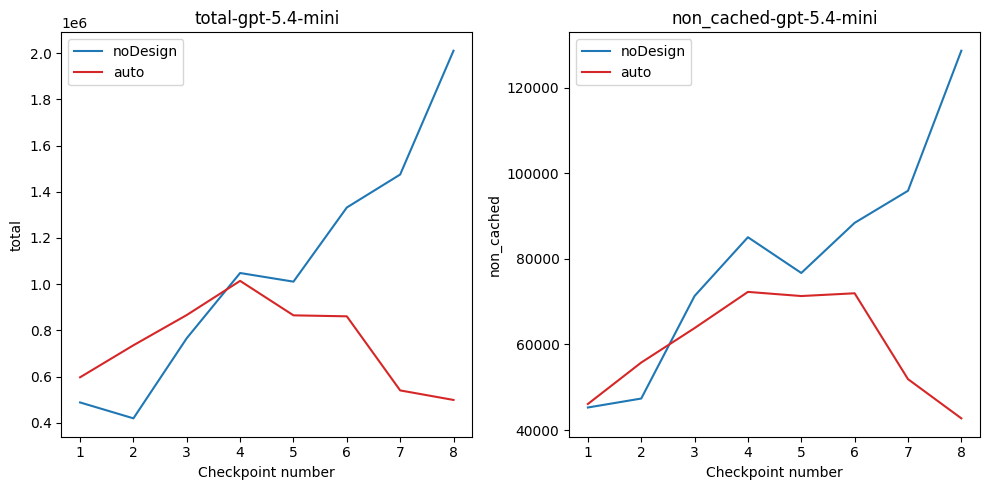

In [96]:
plot(report_metrics_aggregated, ["total", "non_cached"])

## LOC

noDesign, lloc: [230.0, 350.0, 469.62, 559.09, 702.21, 833.12, 987.5, 1168.25]
auto, lloc: [329.38, 503.32, 663.46, 799.89, 984.16, 1190.48, 1466.0, 1724.12]
references-average, lloc: [1565.0, 1892.18, 2193.12, 2349.48, 2508.18, 2806.02, 2813.66, 3252.0]
noDesign, lloc_per_function: [21.09, 20.6, 20.53, 21.75, 21.98, 22.87, 23.4, 23.96]
auto, lloc_per_function: [13.53, 13.01, 12.61, 12.67, 11.9, 11.55, 12.01, 12.14]
references-average, lloc_per_function: [12.16, 12.45, 12.63, 12.76, 12.77, 12.53, 12.22, 12.06]
noDesign, lloc_per_module: [230.0, 350.0, 469.62, 559.09, 702.21, 833.12, 987.5, 1168.25]
auto, lloc_per_module: [59.68, 60.68, 59.59, 56.05, 56.76, 58.38, 56.65, 49.55]
references-average, lloc_per_module: [107.84, 114.77, 119.45, 121.39, 122.19, 121.9, 124.16, 134.54]


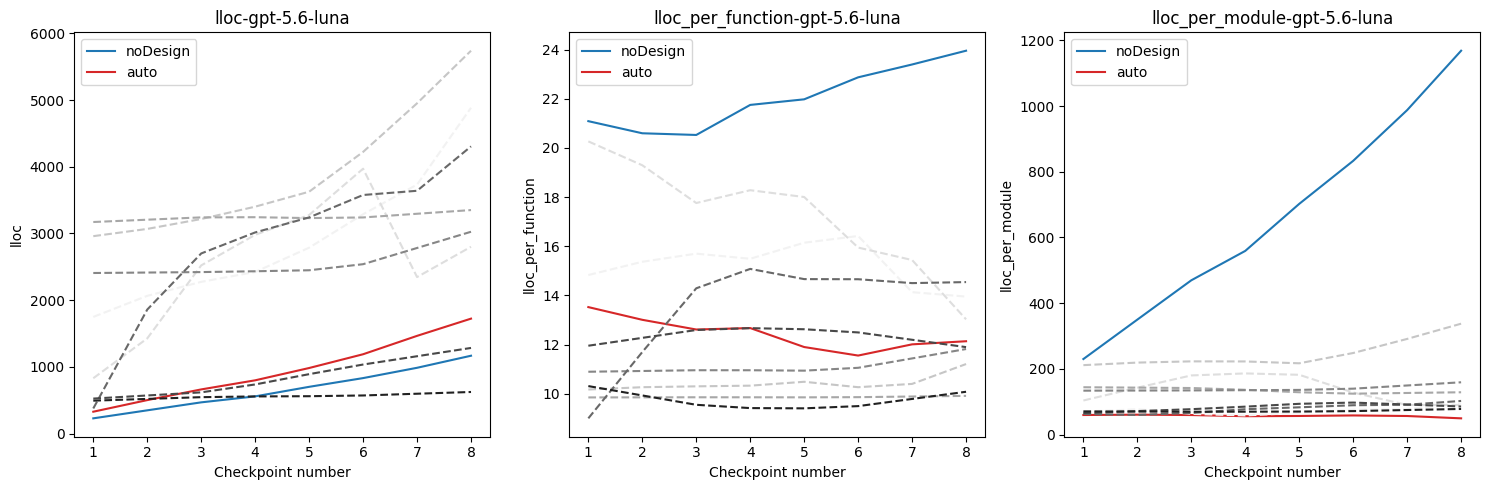

In [113]:
plot(scb_metrics_aggregated, ["lloc", "lloc_per_function", "lloc_per_module"], with_references=True)

## High CC functions and High LOC functions

noDesign, high_cc_functions_count: [1.88, 2.71, 3.88, 4.88, 6.29, 7.0, 8.16, 9.75]
auto, high_cc_functions_count: [0.38, 0.59, 0.75, 0.61, 0.34, 0.64, 0.55, 1.0]
references-average, high_cc_functions_count: [5.38, 6.18, 6.95, 7.43, 7.95, 8.39, 9.0, 9.5]
noDesign, function_max_loc: [92.12, 109.21, 139.43, 124.2, 161.29, 232.77, 276.07, 296.88]
auto, function_max_loc: [58.75, 63.16, 70.73, 73.21, 75.86, 81.84, 87.98, 94.0]
references-average, function_max_loc: [79.12, 87.59, 95.61, 99.29, 100.25, 100.32, 109.5, 136.25]
noDesign, function_max_cc: [18.88, 21.75, 23.86, 24.46, 32.04, 46.52, 54.0, 58.62]
auto, function_max_cc: [9.0, 9.39, 10.41, 11.32, 9.54, 9.02, 8.45, 10.12]
references-average, function_max_cc: [17.5, 20.32, 22.59, 23.66, 23.59, 24.18, 25.55, 26.88]


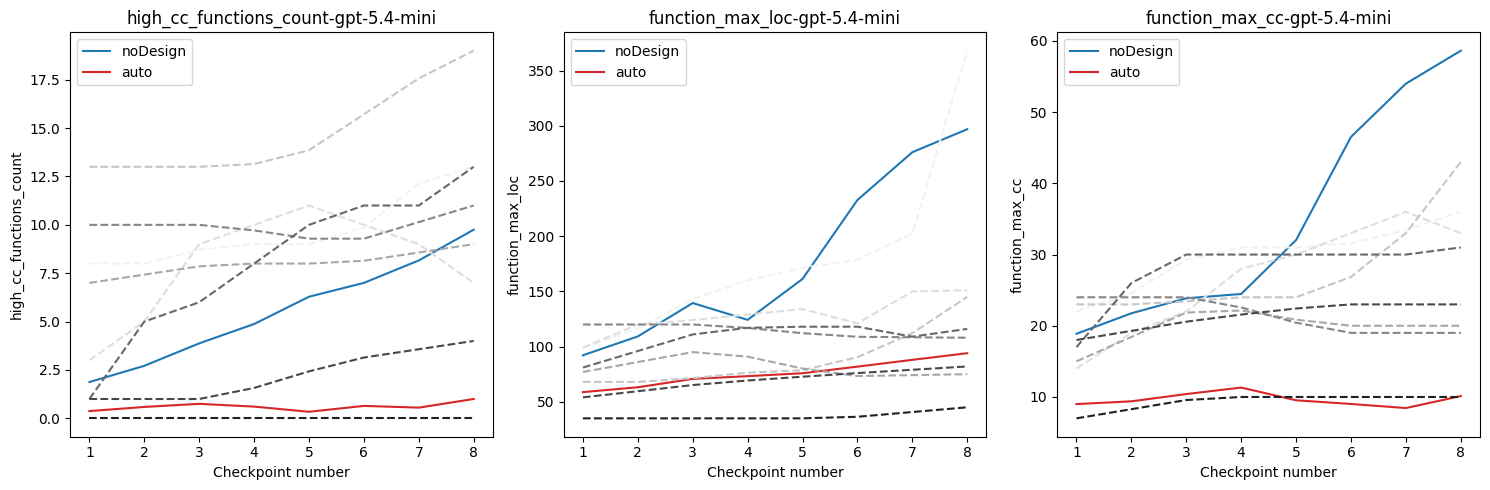

In [98]:
plot(scb_metrics_aggregated, ["high_cc_functions_count", "function_max_loc", "function_max_cc"], with_references=True)

## Weighted MI

noDesign, weighted_mi: [19.6, 10.05, 5.06, 7.52, 3.22, 1.16, 1.83, 1.1]
auto, weighted_mi: [37.76, 37.01, 34.01, 29.78, 28.34, 30.04, 33.73, 31.56]
references-average, weighted_mi: [45.61, 42.46, 41.27, 41.19, 41.45, 41.79, 42.11, 40.93]


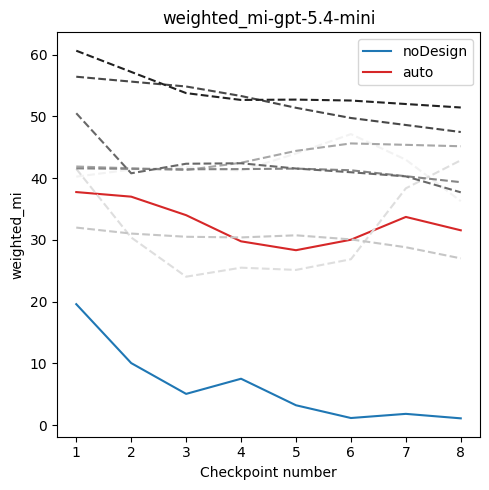

In [99]:
plot(scb_metrics_aggregated, ["weighted_mi"], with_references=True)

## Duplicated lines and tokens

noDesign, duplicated_lines: [0.0, 0.0, 0.01, 0.01, 0.02, 0.03, 0.04, 0.04]
auto, duplicated_lines: [0.0, 0.0, 0.0, 0.01, 0.01, 0.01, 0.0, 0.01]
references-average, duplicated_lines: [0.05, 0.06, 0.05, 0.05, 0.06, 0.09, 0.08, 0.08]
noDesign, duplicated_tokens: [0.0, 0.0, 0.01, 0.01, 0.02, 0.03, 0.04, 0.04]
auto, duplicated_tokens: [0.0, 0.0, 0.0, 0.01, 0.01, 0.01, 0.01, 0.01]
references-average, duplicated_tokens: [0.05, 0.07, 0.06, 0.06, 0.07, 0.09, 0.09, 0.09]


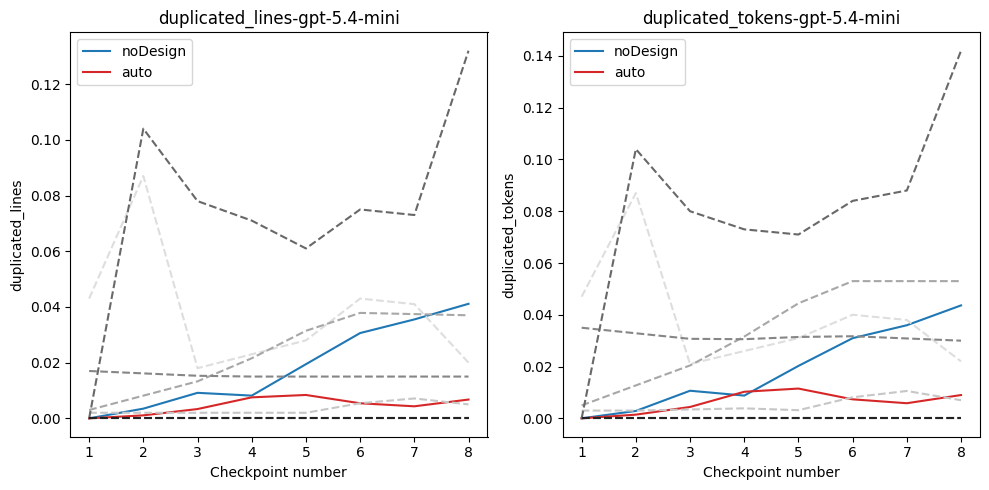

In [100]:
plot(scb_metrics_aggregated, ["duplicated_lines", "duplicated_tokens"], with_references=True)

## Graph average degree

noDesign, average_degree: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
auto, average_degree: [1.75, 1.92, 1.99, 1.99, 2.02, 2.11, 2.24, 2.26]
references-average, average_degree: [2.81, 2.84, 2.91, 2.93, 3.0, 3.11, 3.23, 3.36]


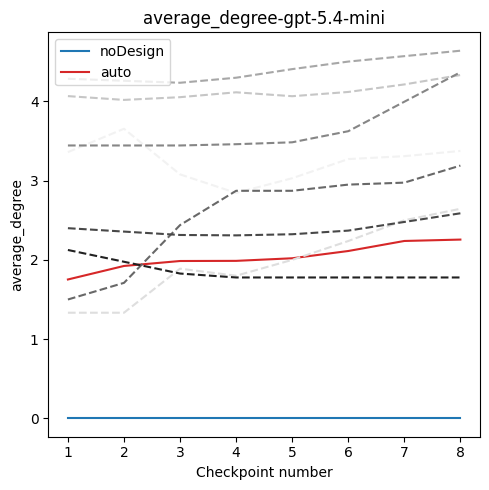

In [101]:
plot(scb_metrics_aggregated, ["average_degree"], with_references=True)

## Number of public methods per module

noDesign, nopm_per_class: [7.87, 8.94, 9.12, 6.24, 9.19, 11.34, 10.51, 11.47]
auto, nopm_per_class: [0.97, 1.07, 1.09, 1.18, 1.55, 1.32, 1.28, 1.27]
references-average, nopm_per_class: [2.62, 2.63, 2.52, 2.41, 2.42, 2.41, 2.28, 2.33]
noDesign, class_max_nopm: [17.25, 23.02, 28.32, 25.57, 32.75, 40.3, 37.12, 36.75]
auto, class_max_nopm: [3.75, 4.73, 4.8, 5.38, 8.55, 9.16, 9.88, 9.88]
references-average, class_max_nopm: [22.38, 24.5, 26.8, 26.86, 26.79, 27.8, 23.7, 24.62]


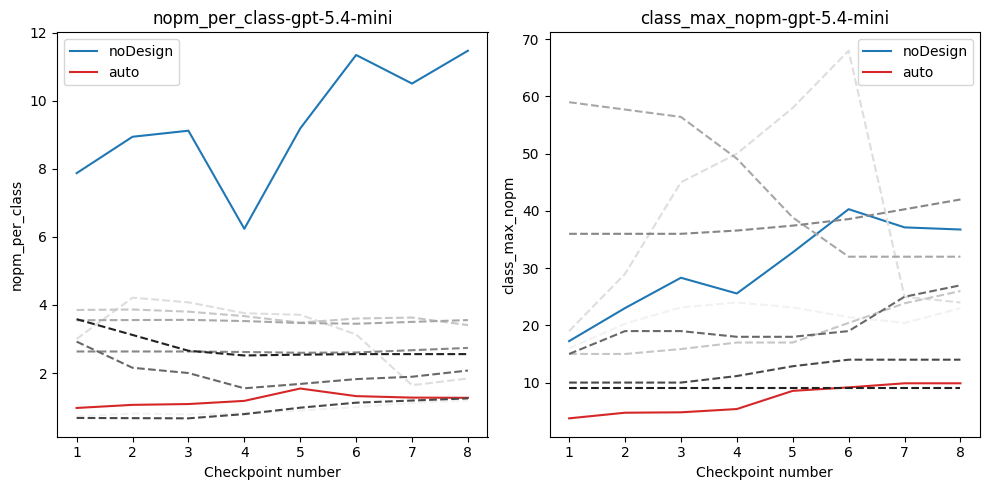

In [102]:
plot(scb_metrics_aggregated, ["nopm_per_class", "class_max_nopm"], with_references=True)

## Number of functions (per module)

noDesign, number_of_functions: [25.25, 32.89, 46.73, 50.14, 65.64, 79.66, 83.16, 88.25]
auto, number_of_functions: [31.25, 48.0, 60.43, 70.0, 84.43, 93.73, 93.55, 100.5]
references-average, number_of_functions: [140.88, 163.98, 180.57, 189.71, 200.36, 226.21, 234.36, 267.12]
noDesign, number_of_functions_per_module: [25.25, 32.89, 46.73, 50.14, 65.64, 79.66, 83.16, 88.25]
auto, number_of_functions_per_module: [7.3, 7.89, 8.43, 8.32, 9.35, 8.91, 8.19, 8.49]
references-average, number_of_functions_per_module: [9.61, 9.82, 10.07, 10.12, 10.12, 10.46, 10.82, 11.53]


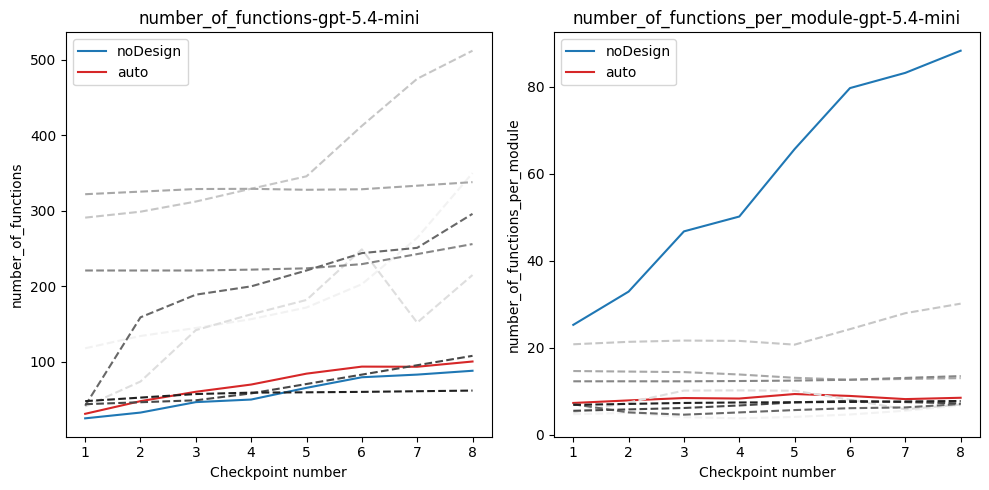

In [103]:
plot(scb_metrics_aggregated, ["number_of_functions", "number_of_functions_per_module"], with_references=True)

## N, Prop cost, impact size

noDesign, number_of_modules: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
auto, number_of_modules: [5.5, 6.73, 7.59, 8.14, 9.0, 10.07, 11.21, 11.88]
references-average, number_of_modules: [13.5, 17.2, 20.39, 21.29, 22.04, 24.29, 24.52, 26.25]
noDesign, propagation_cost: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
auto, propagation_cost: [0.5, 0.46, 0.43, 0.41, 0.39, 0.37, 0.36, 0.36]
references-average, propagation_cost: [0.43, 0.41, 0.39, 0.38, 0.38, 0.39, 0.41, 0.42]
noDesign, impact_size: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
auto, impact_size: [2.01, 2.36, 2.44, 2.58, 2.62, 2.83, 3.1, 3.25]
references-average, impact_size: [5.02, 5.69, 5.83, 6.04, 6.44, 7.29, 8.04, 8.6]


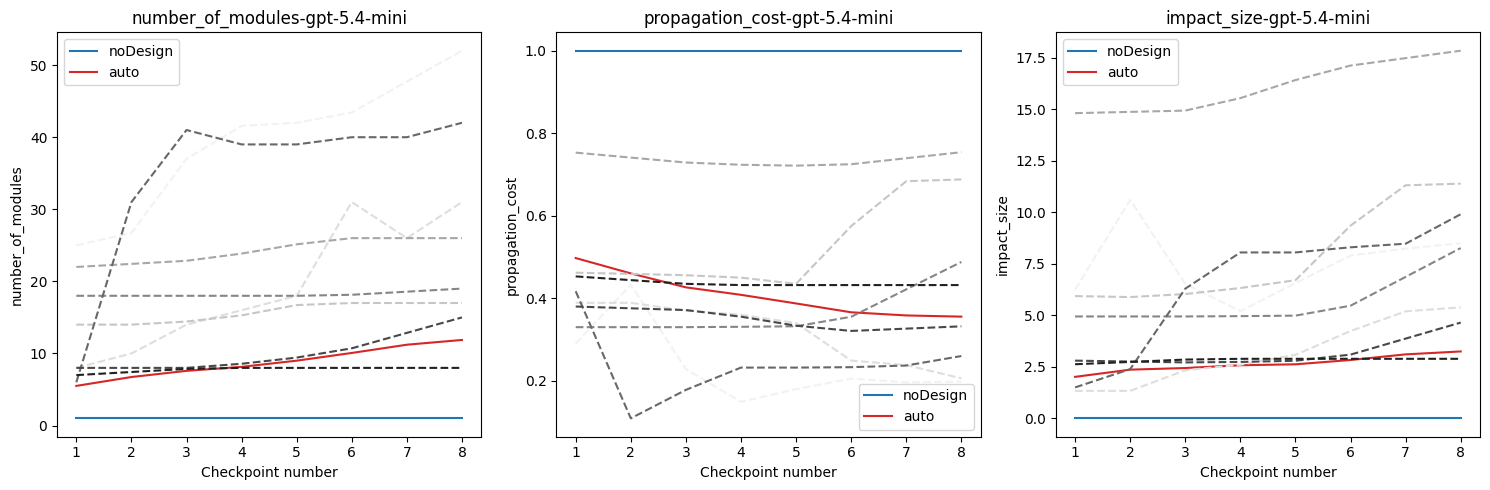

In [104]:
plot(scb_metrics_aggregated, ["number_of_modules", "propagation_cost", "impact_size"], with_references=True)

## Tests pass rate

KeyError: None

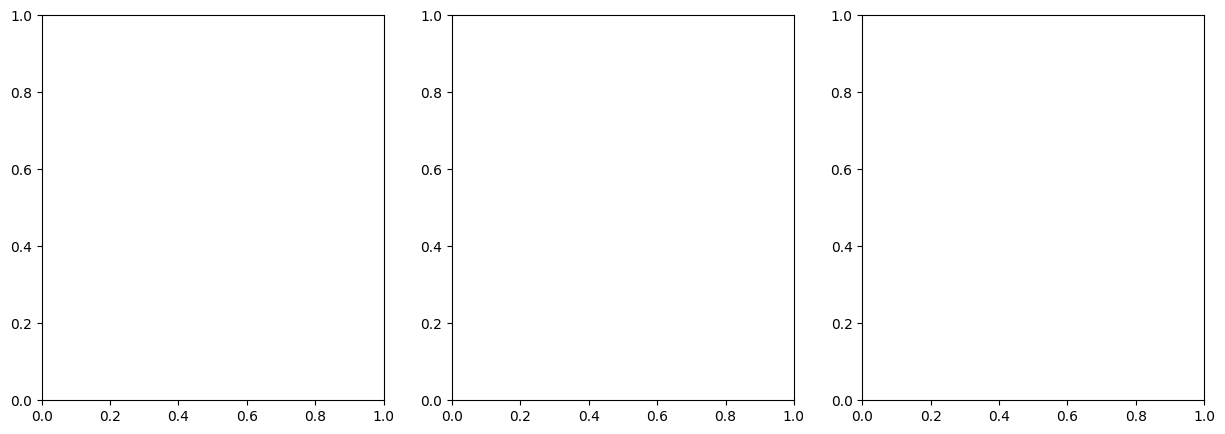

In [105]:
plot(scb_test_metrics, ["current", "prev", "all"])

In [ ]:
# Obtain test pass rates for GPT 5.6 and 5.4 respectively 

target_problems = [
    "code_search", "circuit_eval", "etl_pipeline", "meshctl", "mocked_http", "recli", "sheeteval", "sith"
    ]

def get_pass_rate(problems, mode, model): 
    results = [] 
    key = f"implementations_{mode}_codex_{model}"
    for problem in problems: 
        for entry in scb_test_metrics[problem][key]: 
            results.append(entry) 

    return average(results) 

for mode in ["noDesign", "auto", "autoTest"]: 
    for model in ["gpt-5.6-luna", "gpt-5.4-mini"]: 
        print(f"{mode}, {model}: { {k: round(v, 2) for k, v in get_pass_rate(target_problems, mode, model).items()} }")